## Imports + Configuration

In [1]:
# Core
import os, json, warnings, joblib
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# ML
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_score, recall_score, f1_score
)
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET = "SeriousDlqin2yrs"
DATA_PATH = "/content/financial_risk_loan_raw_dataset.csv"

os.makedirs("/content/artifacts", exist_ok=True)

## Load RAW Data

In [2]:
df = pd.read_csv("/content/financial_risk_loan_raw_dataset.csv")

print(f"Shape: {df.shape}")
display(df.head())

Shape: (15000, 37)


,Applicant_ID,Age,Gender,Marital_Status,Education_Level,Employment_Status,Employment_Years,Home_Ownership,Number_of_Dependents,Monthly_Income,...,Times_30_59_Days_Past_Due,Times_60_89_Days_Past_Due,Times_90_Plus_Days_Past_Due,Times_120_Plus_Days_Past_Due,Late_Payment_Count,Previous_Bankruptcies,Tax_Liens,Delinquency_History,Has_Employment_Income,SeriousDlqin2yrs
0,100001,51,Female,Divorced,Bachelor,Employed,11.5,Rent,3.0,5010.0,...,1,1,0,0,2,0,0,0,Yes,0
1,100002,43,Female,Single,Bachelor,Employed,6.8,Own,1.0,5384.0,...,1,0,0,0,1,0,0,0,Yes,1
2,100003,53,Female,Divorced,Diploma,Employed,1.5,Mortgage,2.0,5735.0,...,0,0,0,0,0,0,1,1,Yes,1
3,100004,63,Male,Married,Bachelor,Employed,7.7,Own,0.0,10178.0,...,0,0,0,0,0,1,0,0,Yes,0
4,100005,42,Female,Divorced,High School,Employed,0.7,Own,0.0,3384.0,...,0,0,1,0,1,0,0,0,Yes,1


## Data Understanding

In [3]:
print("Data Types:\n")
print(df.dtypes)

print("\nMissing Values:\n")
display(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nTarget Distribution:\n")
print(df[TARGET].value_counts())

Data Types:

Applicant_ID                      int64
Age                               int64
Gender                           object
Marital_Status                   object
Education_Level                  object
Employment_Status                object
Employment_Years                float64
Home_Ownership                   object
Number_of_Dependents            float64
Monthly_Income                  float64
Annual_Income                   float64
Credit_Limit                    float64
Credit_Utilization              float64
Credit_History_Years            float64
Total_Credit_Accounts             int64
Open_Credit_Lines                 int64
Credit_Cards                      int64
Installment_Accounts              int64
Real_Estate_Loans                 int64
Debt_Ratio                      float64
Total_Debt                      float64
Loan_Amount                     float64
Loan_Term_Months                  int64
Interest_Rate                   float64
Loan_Purpose               

,0
Monthly_Income,1200
Employment_Years,450
Number_of_Dependents,450
Credit_Limit,300
Credit_History_Years,300
Education_Level,0
Marital_Status,0
Gender,0
Age,0
Applicant_ID,0



Target Distribution:

SeriousDlqin2yrs
0    9848
1    5152
Name: count, dtype: int64


## Data Quality Validation

In [4]:
assert TARGET in df.columns, f"Target '{TARGET}' not found."
assert df[TARGET].isin([0, 1]).all(), "Target must contain only 0/1."
assert df["Applicant_ID"].is_unique, "Applicant_ID must be unique."

print("✅ Data validation passed")

✅ Data validation passed


## EDA Exploratory Data Analysis

In [5]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Applicant_ID,15000.0,NaN,NaN,NaN,107500.5,4330.271354,100001.0,103750.75,107500.5,111250.25,115000.0
Age,15000.0,NaN,NaN,NaN,45.1264,11.760387,21.0,37.0,45.0,53.0,85.0
Gender,15000,3,Female,7378,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,15000,4,Married,7270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Level,15000,5,Bachelor,5206,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Employment_Status,15000,4,Employed,9708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Employment_Years,14550.0,NaN,NaN,NaN,8.242378,5.528489,0.0,3.9,8.0,12.0,33.1
Home_Ownership,15000,3,Mortgage,7137,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number_of_Dependents,14550.0,NaN,NaN,NaN,1.499107,1.220753,0.0,1.0,1.0,2.0,8.0
Monthly_Income,13800.0,NaN,NaN,NaN,6776.442609,4858.456697,800.0,3526.0,5506.0,8561.5,60000.0


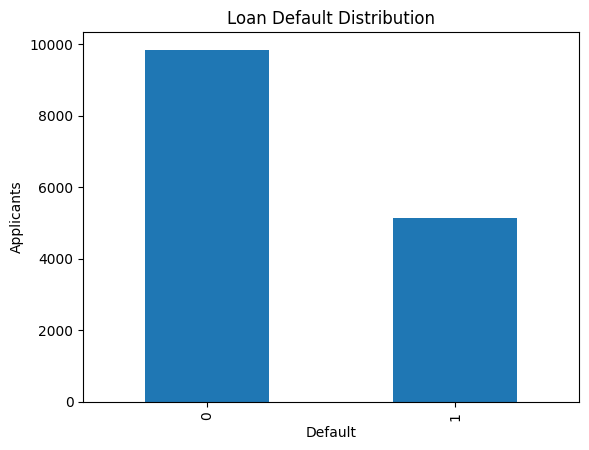

In [6]:
df[TARGET].value_counts().plot(kind="bar")
plt.title("Loan Default Distribution")
plt.xlabel("Default")
plt.ylabel("Applicants")
plt.show()

## Reusable Feature Engineering Transformer

In [8]:
from sklearn.base import BaseEstimator, TransformerMixin

class FinancialFeatureEngineer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        eps = 1e-6

        X["Income_Per_Dependent"] = (
            X["Monthly_Income"] / (X["Number_of_Dependents"] + 1)
        )

        X["Loan_to_Income"] = (
            X["Loan_Amount"] / (X["Annual_Income"] + eps)
        )

        X["Debt_to_Income"] = (
            X["Total_Debt"] / (X["Annual_Income"] + eps)
        )

        X["Available_Credit"] = (
            X["Credit_Limit"] * (1 - X["Credit_Utilization"].clip(0, 1))
        )

        X["Monthly_Loan_Burden"] = (
            X["Loan_Amount"] / (X["Loan_Term_Months"] + eps)
        )

        X["Delinquency_Score"] = (
            X["Times_30_59_Days_Past_Due"] +
            2 * X["Times_60_89_Days_Past_Due"] +
            3 * X["Times_90_Plus_Days_Past_Due"] +
            4 * X["Times_120_Plus_Days_Past_Due"]
        )

        X["Credit_Utilization_Risk"] = (
            X["Credit_Utilization"] > 0.70
        ).astype(int)

        X["Recent_Late_Payment_Rate"] = (
            X["Late_Payment_Count"] /
            (X["Credit_History_Years"] * 12 + 1)
        )

        X["Credit_Account_Density"] = (
            X["Total_Credit_Accounts"] /
            (X["Credit_History_Years"] + 1)
        )

        return X

## Separate Features and Target

In [9]:
X = df.drop(columns=[TARGET, "Applicant_ID"])
y = df[TARGET]

print("Features:", X.shape[1])
print("Samples :", X.shape[0])

Features: 35
Samples : 15000


## Train/Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (12000, 35)
Test : (3000, 35)


## Detect Numerical + Categorical Features

In [11]:
feature_engineer = FinancialFeatureEngineer()

X_train_fe = feature_engineer.fit_transform(X_train)

numeric_features = X_train_fe.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X_train_fe.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical:", len(numeric_features))
print("Categorical:", len(categorical_features))

Numerical: 36
Categorical: 8


## Enterprise Preprocessing Pipeline

#### We handle missing values inside the pipeline.

In [12]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## ML Model

In [13]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

## Complete ML Pipeline

In [14]:
ml_pipeline = Pipeline([
    ("feature_engineering", FinancialFeatureEngineer()),
    ("preprocessing", preprocessor),
    ("model", model)
])

ml_pipeline.fit(X_train, y_train)

print("✅ Model training completed")

✅ Model training completed


## Model Evaluation

In [15]:
y_pred = ml_pipeline.predict(X_test)
y_prob = ml_pipeline.predict_proba(X_test)[:, 1]

metrics = {
    "ROC_AUC": roc_auc_score(y_test, y_prob),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred)
}

print(pd.Series(metrics).round(4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

ROC_AUC      0.7204
Precision    0.5610
Recall       0.5087
F1           0.5336
dtype: float64

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.79      0.77      1970
           1       0.56      0.51      0.53      1030

    accuracy                           0.69      3000
   macro avg       0.66      0.65      0.65      3000
weighted avg       0.69      0.69      0.69      3000



## Confusion Matrix

In [16]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1560  410]
 [ 506  524]]


## Save the Complete Model Artifact

In [17]:
artifact = {
    "model": ml_pipeline,
    "target": TARGET,
    "features": X.columns.tolist(),
    "metrics": metrics,
    "version": "1.0.0"
}

joblib.dump(
    artifact,
    "/content/artifacts/financial_risk_model.joblib"
)

print("✅ Model artifact saved")

✅ Model artifact saved


## Test With Completely Unseen Applicant Data


In [18]:
unseen = X_test.iloc[[0]].copy()

prediction = ml_pipeline.predict(unseen)[0]
probability = ml_pipeline.predict_proba(unseen)[0, 1]

print("Risk Class:", prediction)
print("Default Probability:", round(probability, 4))

Risk Class: 0
Default Probability: 0.3921
